In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from joblib import dump

In [8]:


data = pd.read_csv("collected_features.csv") 

# Вывод первых 5 строк
print(data.head())

   label  rel_x_0  rel_y_0  rel_x_1  rel_y_1  rel_x_2  rel_y_2  rel_x_3  \
0      1      0.0      0.0  0.00047 -0.09704  0.00900 -0.19505  0.01485   
1      1      0.0      0.0 -0.08250 -0.08861 -0.13320 -0.20793 -0.17168   
2      1      0.0      0.0 -0.05352 -0.06293 -0.07542 -0.14084 -0.06950   
3      1      0.0      0.0 -0.04407 -0.06826 -0.06250 -0.16108 -0.04708   
4      1      0.0      0.0 -0.05129 -0.06258 -0.08108 -0.14496 -0.08576   

   rel_y_3  rel_x_4  ...  delta_x_t2_18  delta_y_t2_18  delta_x_t2_19  \
0 -0.28914  0.00981  ...        0.00330       -0.04143        0.00716   
1 -0.29937 -0.19418  ...        0.08598        0.04334        0.07794   
2 -0.20499 -0.04749  ...        0.03682        0.05152        0.03812   
3 -0.22169 -0.01082  ...       -0.00044        0.05170       -0.00457   
4 -0.20178 -0.06920  ...        0.04186        0.11123        0.04236   

   delta_y_t2_19  delta_x_t2_20  delta_y_t2_20   v_x_t2   v_y_t2   a_x_t2  \
0       -0.03153        0.01096  

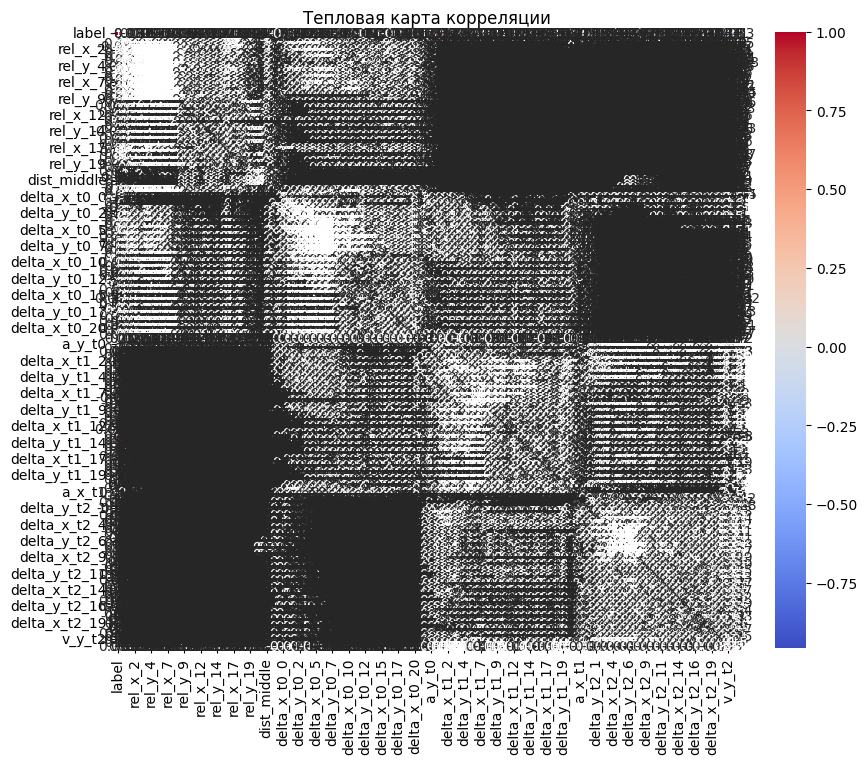

In [4]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Тепловая карта корреляции")
plt.show()

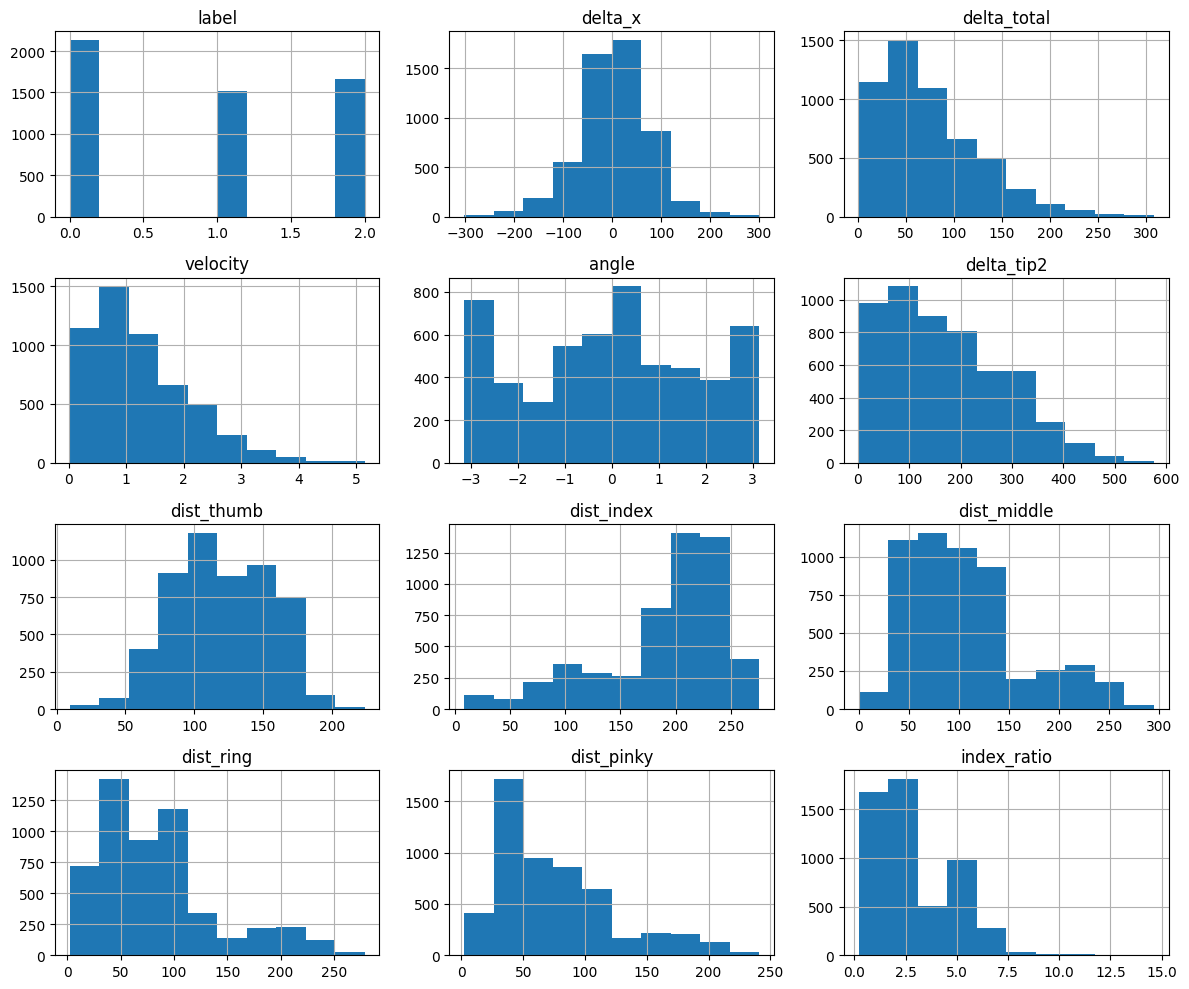

In [16]:
data.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

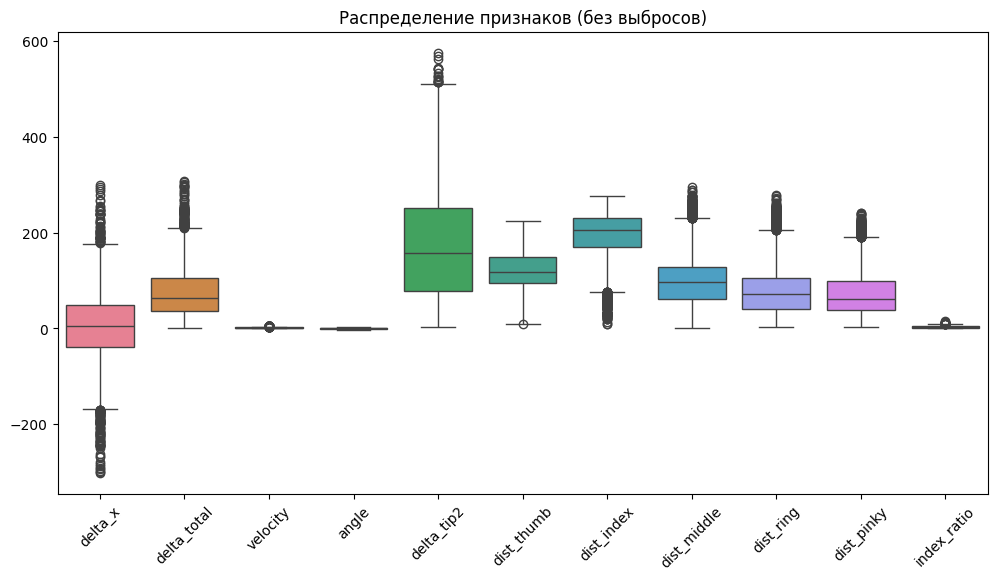

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data.drop('label', axis=1))
plt.xticks(rotation=45)
plt.title("Распределение признаков (без выбросов)")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Разделение данных
X = data.drop('label', axis=1)
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Обучение модели
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Предсказание и оценка
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        75
           2       1.00      1.00      1.00        63

    accuracy                           1.00       178
   macro avg       1.00      1.00      1.00       178
weighted avg       1.00      1.00      1.00       178

Accuracy: 1.00


In [6]:
# Шаг 1: Взвешивание классов
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Шаг 2: Подбор параметров для улучшенной модели
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train, y_train)

# Итоговый отчёт
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        75
           2       1.00      1.00      1.00        63

    accuracy                           1.00       178
   macro avg       1.00      1.00      1.00       178
weighted avg       1.00      1.00      1.00       178



In [28]:
# Сохранение
dump(model, 'model.joblib')

['model.joblib']